# CNASim Benchmark

This notebook analyses the results of the experiments.

In [1]:
import os

import scgenome.plotting as pl
import seaborn as sns
import anndata
from Bio import Phylo
from io import StringIO
import pandas as pd

from cellmates.utils.tree_utils import make_gt_tree_dist

/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/scgenome/refgenome.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
input = snakemake.input[0]
# input = "../../results/stats.csv"

In [35]:
stats_df = pd.read_csv(input)
stats_df.describe()

,seed,n_cells,n_states,n_clones,n_sites,lambda,ru_mse,uv_mse,uw_mse,rf,urf,nrf,f1_gt,f1_em
count,12.000000,12.000000,12.0,12.000000,12.000000,12.0,1.200000e+01,1.200000e+01,1.200000e+01,12.000000,12.000000,12.000000,12.000000,12.000000
mean,2.000000,24.000000,7.0,3.250000,300.000000,2.0,1.278691e-04,7.181069e-05,5.496494e-04,0.154210,13.500000,0.282895,0.909027,0.878725
std,0.852803,16.711455,0.0,0.753778,208.893187,0.0,3.117288e-04,1.194773e-04,1.097470e-03,0.226261,14.222262,0.183968,0.109103,0.125244
min,1.000000,8.000000,7.0,2.000000,100.000000,2.0,1.326935e-07,1.237142e-07,3.329936e-07,0.006439,0.000000,0.000000,0.718077,0.700290
25%,1.000000,8.000000,7.0,3.000000,100.000000,2.0,2.117904e-06,1.718147e-06,6.205407e-06,0.026091,2.000000,0.166667,0.837302,0.767857
50%,2.000000,24.000000,7.0,3.000000,300.000000,2.0,1.847496e-05,7.269222e-06,5.091589e-05,0.049519,9.000000,0.223684,0.963217,0.940172
75%,3.000000,40.000000,7.0,4.000000,500.000000,2.0,3.353239e-05,6.596341e-05,2.246266e-04,0.135047,18.500000,0.421053,0.990779,0.990779
max,3.000000,40.000000,7.0,4.000000,500.000000,2.0,1.079510e-03,3.251948e-04,3.112235e-03,0.689743,48.000000,0.631579,1.000000,1.000000


## Data plots
Plot CN, trees, reads to verify the quality and complexity of the data.

### Small tree
#### Data

In [13]:
min_n_cells = stats_df['n_cells'].min()
# dat_dir = os.path.join('../../', os.path.dirname(stats_df[stats_df['n_cells'] == min_n_cells]['dat_path'].iloc[0]))
dat_dir = os.path.dirname(stats_df[stats_df['n_cells'] == min_n_cells]['dat_path'].iloc[0])
dat_dir

'../../results/data/R1_N10_M100_K2_L2_E10.04_E20.1_C2'

In [17]:
# plot example
adata = anndata.read_h5ad(os.path.join(dat_dir, "input.h5ad"))
bio_tree = Phylo.read(StringIO(adata.uns['cell-tree-newick']), 'newick')
# use tree from cn-derived branch lengths
cell_names = adata[~adata.obs['normal']].obs_names.tolist()
dpy_tree, gt_ctr = make_gt_tree_dist(adata, n_states=7, cell_names=cell_names)
# rename dpy tree cells
for leaf in dpy_tree.leaf_node_iter():
    leaf.taxon.label = cell_names[int(leaf.taxon.label)]
bio_tree_cn_lengths = Phylo.read(StringIO(dpy_tree.as_string(schema='newick')), 'newick')
adata

AnnData object with n_obs × n_vars = 10 × 100
    obs: 'normal', 'clone'
    var: 'chr', 'start', 'end'
    uns: 'ancestral-cn', 'ancestral-cnA', 'ancestral-cnB', 'ancestral-names', 'cell-tree-newick', 'clonal-tree-newick', 'clone-id-tree-newick', 'cnasim-params'
    layers: 'Acopy', 'Acount', 'Astate', 'Bcopy', 'Bcount', 'Bstate', 'copy', 'state'

/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/scgenome/plotting/heatmap.py:394: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['phylo_order'] = -1


Text(0.5, 0.98, 'Target (GT)')

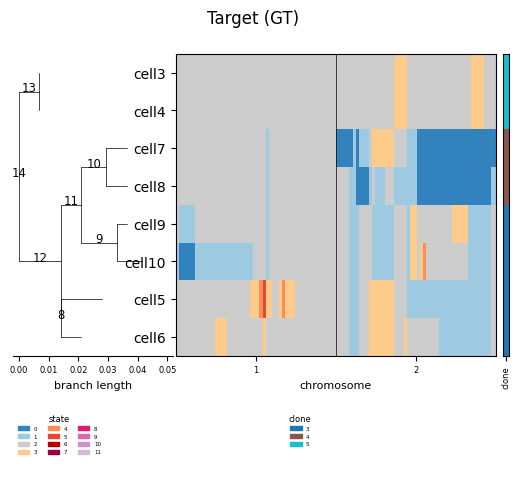

In [22]:
g = pl.plot_cell_cn_matrix_fig(adata[~adata.obs['normal']], layer_name='state', tree=bio_tree_cn_lengths, annotation_fields=['clone'], show_cell_ids=True)
g['fig'].suptitle('Target (GT)');

Text(0.5, 0.98, 'Observation (GT) - with normal cells')

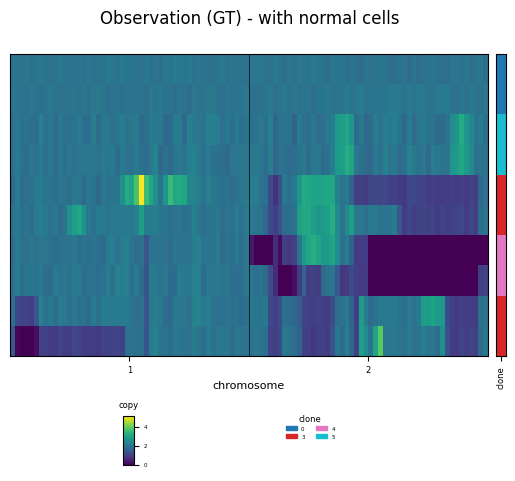

In [58]:
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='copy', annotation_fields=['clone'], raw=True)
g['fig'].suptitle('Observation (GT) - with normal cells');

#### Inferred

/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/scgenome/plotting/heatmap.py:394: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['phylo_order'] = -1


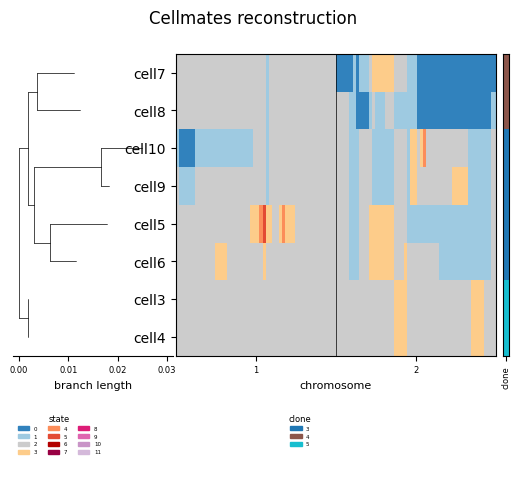

In [25]:
em_nwk = open(os.path.join(dat_dir, "cm_out", "tree.nwk")).read()
inferred_tree = Phylo.read(os.path.join(dat_dir, "cm_out", "tree.nwk"), 'newick')
g = pl.plot_cell_cn_matrix_fig(adata[~adata.obs['normal']], layer_name='state', tree=inferred_tree, annotation_fields=['clone'], show_cell_ids=True)
g['fig'].suptitle('Cellmates reconstruction');

# Benchmarks

## Robinson Fould

In [29]:
# place rf, urf, nrf in same col 'metric'
rf_melt = pd.melt(stats_df,
                  id_vars=['n_cells', 'n_sites'],
                  value_vars=['rf', 'urf', 'nrf'],
                  var_name='metric',
                  value_name='value'
                  )
rf_melt.head()

,n_cells,n_sites,metric,value
0,8,100,rf,0.044455
1,8,500,rf,0.015526
2,40,100,rf,0.340252
3,40,500,rf,0.066645
4,8,100,rf,0.061522


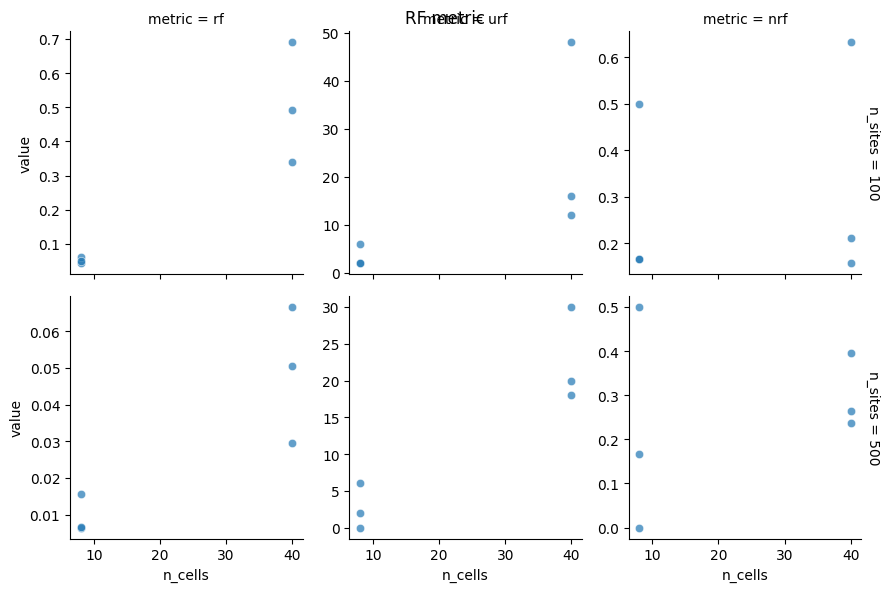

In [37]:
# plot RF distance
g = sns.FacetGrid(rf_melt, row='n_sites', col='metric', margin_titles=True, sharey=False)
g.map(sns.scatterplot, 'n_cells', 'value', alpha=0.7)
g.fig.suptitle('RF metric');

## F1 metric (against GT)

In [45]:
f1_melt = pd.melt(stats_df,
                  id_vars=['n_cells', 'n_sites', 'seed'],
                  value_vars=['f1_gt', 'f1_em'],
                  var_name='metric',
                  value_name='value'
                  )
f1_melt.head()


,n_cells,n_sites,seed,metric,value
0,8,100,1,f1_gt,0.933333
1,8,500,1,f1_gt,0.857143
2,40,100,1,f1_gt,0.969697
3,40,500,1,f1_gt,0.987705
4,8,100,2,f1_gt,0.777778


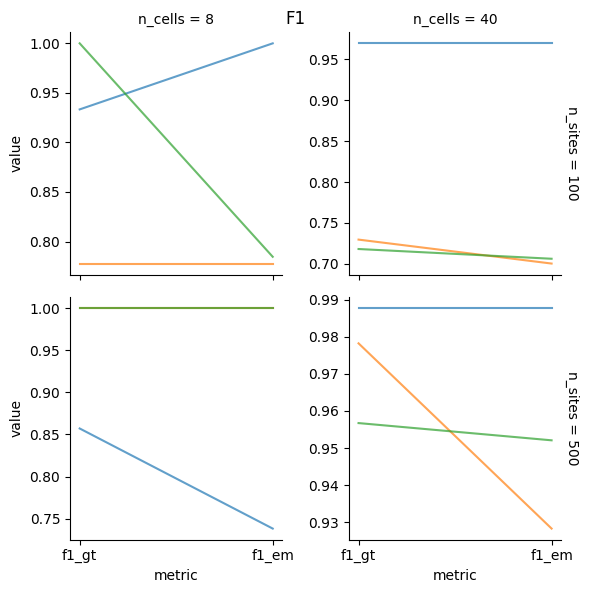

In [52]:
g = sns.FacetGrid(f1_melt, row='n_sites', col='n_cells', margin_titles=True, sharey=False, hue='seed')
g.map(sns.lineplot, 'metric', 'value', alpha=0.7, markers=True)
g.fig.suptitle('F1');


## Branch lengths error

In [53]:
err_melt = pd.melt(stats_df,
                  id_vars=['n_cells', 'n_sites'],
                  value_vars=['ru_mse', 'uv_mse', 'uw_mse'],
                  var_name='metric',
                  value_name='value'
                  )
err_melt.head()

,n_cells,n_sites,metric,value
0,8,100,ru_mse,0.000032
1,8,500,ru_mse,0.000003
2,40,100,ru_mse,0.000038
3,40,500,ru_mse,0.000003
4,8,100,ru_mse,0.000032


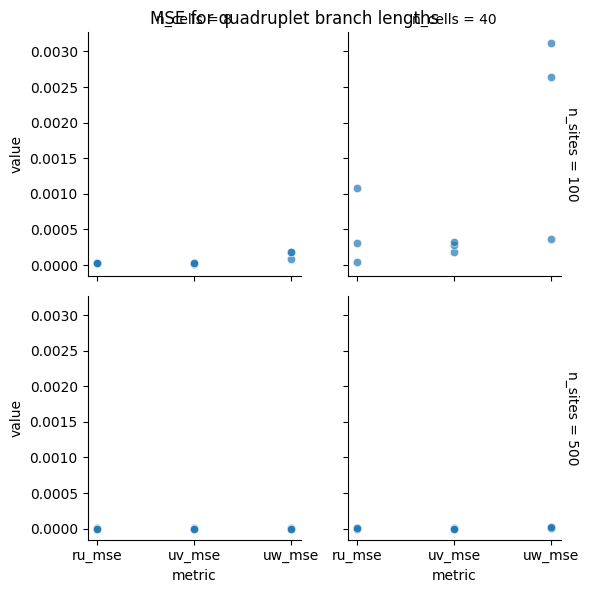

In [57]:
g = sns.FacetGrid(err_melt, row='n_sites', col='n_cells', margin_titles=True, sharey=True)
g.map(sns.scatterplot, 'metric', 'value', alpha=0.7)
g.fig.suptitle('MSE for quadruplet branch lengths');